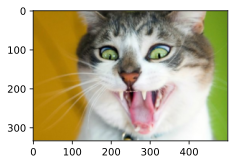

In [3]:
%matplotlib inline
import torch
import torchvision as tv
from torch import nn
from d2l import torch as d2l

d2l.set_figsize()
img=d2l.Image.open('../img/cat.jpg')
d2l.plt.imshow(img)

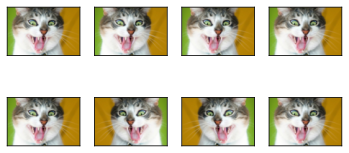

In [7]:
#数据增强
def appay(img,aug,num_rows=2,num_cols=4,scale=1.5):
    Y=[aug(img) for _ in range(num_rows*num_cols)]
    d2l.show_images(Y,num_rows,num_cols,scale=scale)

appay(img,tv.transforms.RandomHorizontalFlip()) #水平方向随机反转

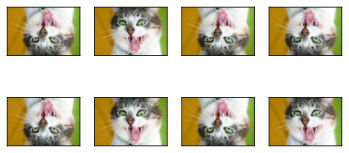

In [8]:
appay(img,tv.transforms.RandomVerticalFlip()) #上下方向随机反转

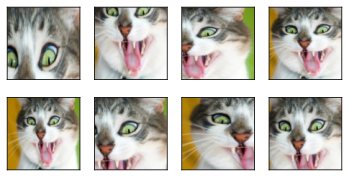

In [10]:
# 随机剪裁
shape_aug=tv.transforms.RandomResizedCrop(
    (200,200),scale=(0.1,1),ratio=(0.5,2)
)
appay(img,shape_aug)

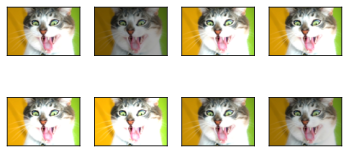

In [13]:
#随机亮度
appay(img,tv.transforms.ColorJitter(
    brightness=0.5,contrast=0,saturation=0,hue=0)
)

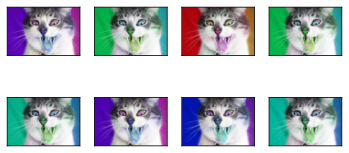

In [14]:
# 随机改变图片的色调
appay(img,tv.transforms.ColorJitter(
    brightness=0,contrast=0,saturation=0,hue=0.5)
)

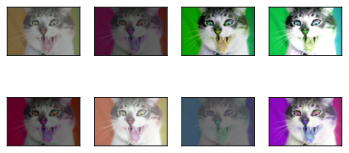

In [17]:
#随机改变图片的亮度，对比度，饱和度，色调
color_aug=tv.transforms.ColorJitter(
    brightness=0.6,contrast=0.7,saturation=0.4,hue=0.5)
appay(img,color_aug)


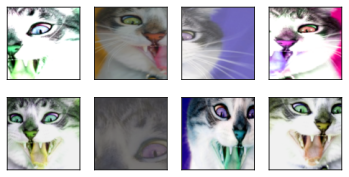

In [18]:
# 结合多种图像增广方法
augs=tv.transforms.Compose([
    tv.transforms.RandomHorizontalFlip(),
    color_aug,
    shape_aug
])
appay(img,augs)

In [24]:
# 训练
all_images=tv.datasets.CIFAR10(
    train=True,root="../data",download=True)
d2l.show_images([
    all_images[i][0] for i in range(32)],4,8,scale=0.8);

PermissionError: [Errno 13] Permission denied: '../data\\cifar-10-python.tar.gz'